In [189]:
from astropy.io import fits
from astropy.table import Table
from astropy.table import vstack
import matplotlib.pyplot as plt
import numpy as np
import os
import corner
import asdf
import numpyro

from pysersic.results import plot_image, plot_residual
from pysersic import check_input_data
from pysersic.priors import autoprior
from pysersic import FitSingle
from pysersic.loss import student_t_loss, gaussian_loss
from jax.random import PRNGKey


# FILTERS =["F606W", "F814W","F115W", "F150W", "F200W", "F277W", "F356W", "F444W"]
FILTERS = ["F356W"] # most important filters

with fits.open("/nvme/scratch/work/alberttg/Summer_project/Ha_and_NII_broad_line_data.fits") as hdul:
        data = hdul[1].data
TABLE = Table(data)


In [190]:
def make_mask(data, id, filt):
    """
    Makes a mask for a cutout.

    Parameters
    ----------
        data : array-like
            data will be the segmentation info
        path : string
            path to my cutout folder for galaxy of given id
    Returns
    -------
        newhdu : array-like
            mask data
    """
    size = 32 # Automate this later

    x0 = int((size/2) - 1)
    y0 = x0
    data[data == data[x0,y0]] = 0  #change object to 0
    data[data > 0 ] = 1 #change other objects to 1
    newhdu=fits.PrimaryHDU(data)
    newhdu.writeto(f"/nvme/scratch/work/alberttg/Summer_project/Cutouts/{id}/{filt}_mask.fits", overwrite=True)
    # print(f'{ID} final mask saved as "{ID}mask_final.fits"')
        

In [191]:
def load_data(cutout_path, psf_path, id, filt):
    """
    Parameters
    ----------
        cutout_path : str

        psf_path : str

    Returns
    -------
        im : array-lie
            Science image data

        sig : array-like
            Weighted error map

        mask : array-like
            Mask made from segmentation data

        psf : array-like
            Normalised psf data
    """
    cutout = fits.open(cutout_path)

    im = cutout[1].data # science image data
    seg = cutout[2].data # Segmentation map
    sig = cutout[3].data # rms error map of uncertainties
    make_mask(seg, id, filt)
    mask = fits.open(f"/nvme/scratch/work/alberttg/Summer_project/Cutouts/{id}/{filt}_mask.fits")[0].data
    # mask.info()

    psf = fits.open(psf_path)[0].data # psf data

    # Cropping the psf because its 4as but I need it to be 0.96as to match my cutouts
    if len(psf) > len(im):
        # Crop centered
        diff = len(psf) - len(im)
        start = diff // 2
        end = start + len(im)
        psf = psf[start:end, start:end]
            
    # Normalise psf data 
    psf = psf / np.sum(psf) 

    # check_input_data(data=im, rms=sig, psf=psf, mask=mask) # Returns True if all checks pass, otherwise raises warning.

    fig, ax = plot_image(im,mask,sig,psf)
             
    return im, sig, mask, psf




In [192]:
def fitting(im, sig, mask, psf, id, filt):

    prior = autoprior(image = im, profile_type = 'sersic', mask=mask, sky_type = 'flat')
    print("prior: ",prior)
    # profile_type can be 'sersic', 'pointsource', 'exponential', 'devaucoleurs'
    # or a choice of compound profiles: "doublesersic" (2 sersic profiles with a shared center and PA), "sersic_pointsource" (shared center)

    fitter = FitSingle(data=im, rms=sig, mask=mask, psf=psf, prior=prior, loss_func=gaussian_loss)

    # loss_func can take on loss functions like Cash loss using 
    # Poisson Statistics(Cash 1979), 
    # Gaussian loss with a free systematic scatter parameter
    # Gaussian mixture loss with representing an outlier distribution

    map_params = fitter.find_MAP(rkey=PRNGKey(1000)) # map_params is a different way of generating a model sersic profile

    fig,ax = plot_residual(im,map_params['model'],mask=mask,vmin=-1,vmax=1)
    
    fitter.sample()
    sampling_res = fitter.sampling_results
    sampling_res.summary()

    results = fitter.sampling_results.retrieve_param_quantiles(return_dataframe=True) # returns 16th,50th,84th percentile values

    output_dir = f"/nvme/scratch/work/alberttg/Summer_project/Sersic_fits/{id}"
    os.makedirs(output_dir, exist_ok=True)

    fitter.sampling_results.save_result(f"{output_dir}/{filt}_single_sersic_data.asdf")
    
    return results, map_params

In [193]:
def corner_plot(id, filt):

    output_dir = f"/nvme/scratch/work/alberttg/Summer_project/Sersic_fits/{id}"
    os.makedirs(output_dir, exist_ok=True)

    af = asdf.open(f"{output_dir}/{filt}_single_sersic_data.asdf")
    # af.info()
    fig = corner.corner(af.tree["posterior"]) # Creates corner plot

    plt.savefig(os.path.join(output_dir, f"{filt}_single_sersic_corner_plot.png"), dpi=300, bbox_inches="tight", facecolor="white")
    plt.clf()

In [194]:
def run_for_all_galaxies(table):
    """
    """
    # ids = table["SURVEY_ID"]
    ids = [104399]
    surveys = ['PRIMER-UDS']


    # surveys = table["SURVEY"]

    for i in range(len(ids)):
        for filt in FILTERS:

            cutout_path = f"/nvme/scratch/work/alberttg/Summer_project/Cutouts/{ids[i]}/{filt}.fits"

            psf_path = f"/nvme/scratch/work/alberttg/Summer_project/PSFs/{surveys[i]}/{filt}_psf_norm.fits"

            im, sig, mask, psf = load_data(cutout_path, psf_path, ids[i], filt)

            fitting(im, sig, mask, psf, ids[i], filt)
            corner_plot(ids[i], filt)

            break
        break

prior:  Prior for a sersic source:
--------------------------
flux ---  Normal w/ mu = 3.22, sigma = 3.59
xc ---  Normal w/ mu = 15.39, sigma = 1.00
yc ---  Normal w/ mu = 16.40, sigma = 1.00
r_eff ---  Truncated Normal w/ mu = 3.25, sigma = 3.61, between: 0.50 -> inf
ellip ---  Uniform between: 0.00 -> 0.90
theta ---  Custom prior of type: <class 'numpyro.distributions.directional.VonMises'>
n ---  Uniform between: 0.65 -> 8.00

Sky Type: flat
Sky level --- Normal w/ mu = 7.0e-05, sigma = 2.0e-04



ValueError: Normal distribution got invalid loc parameter.

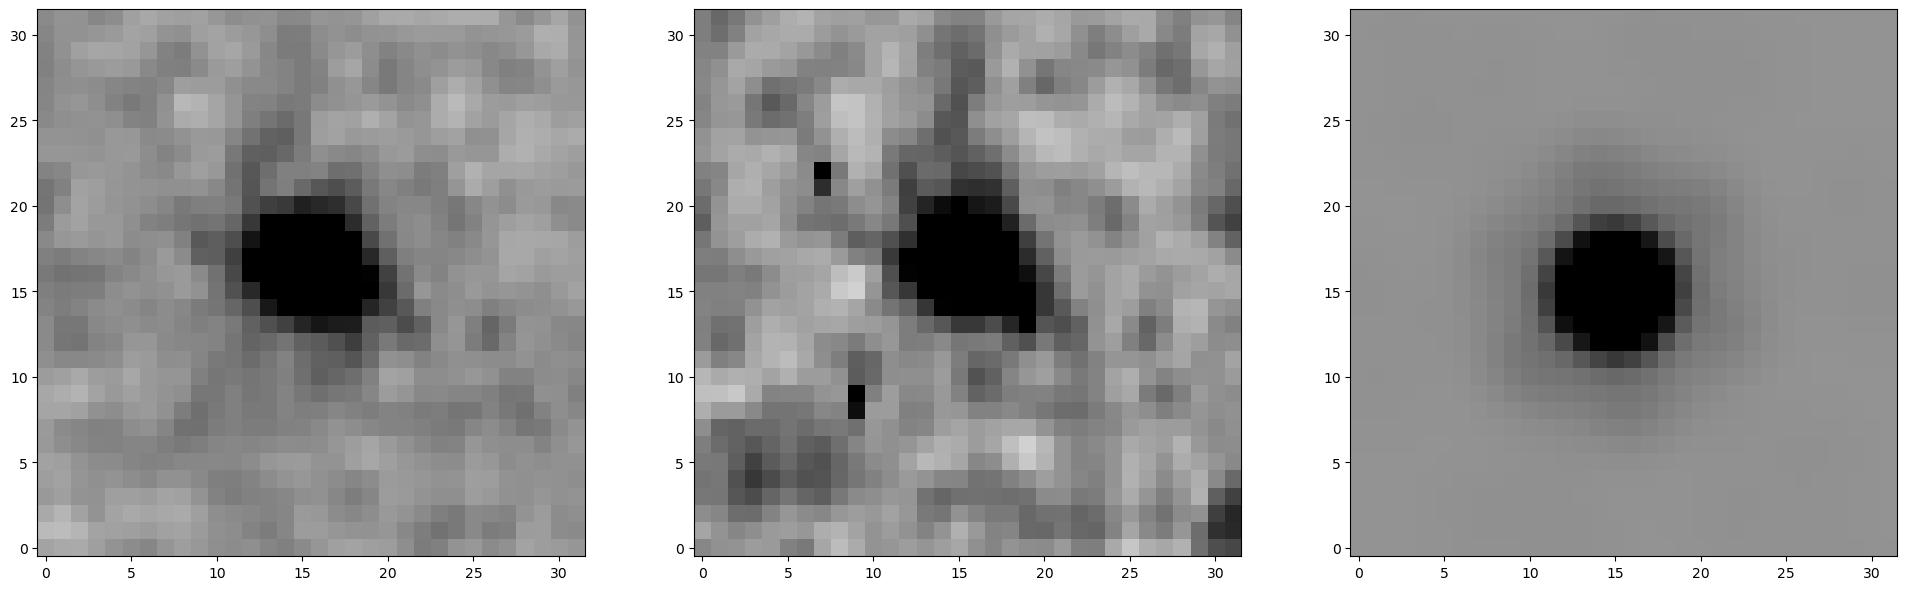

In [195]:
run_for_all_galaxies(TABLE)

In [ ]:
import subprocess

# subprocess.run(f"python /nvme/scratch/work/westcottl/Codes/Morfometryka/Code/morfometryka965.py {science_path} {psf_path} noshow", shell=True)